In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
# 1. Load data
df  = pd.read_csv("cleaned_dataset.csv")

**Setting up Data**

In [ ]:
# Select features (log transform for elasticity)
df = df[(df['Number Booked'] > 0) & (df['PriceINR'] > 0)].copy()

In [ ]:
# Features and target
features = ['PriceINR', 'MaxBookees', 'Hour', 'Month', 'DayOfWeekNum']
X = df[features]
y = df['Number Booked']

In [ ]:
# Split data into 80% train data and 20% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Data ready: {len(X_train)} train, {len(X_test)} test rows")

Data ready: 2616 train, 655 test rows


**Step 2: Model 1 - Linear OLS**

Simple linear regression with stats summary

In [ ]:
# Add constant for intercept
X_train_sm =  sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Fit OLS model
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Print summary
print(ols_model.summary())

# Price elasticity (approximate)
ols_elasticity = ols_model.params['PriceINR'] * (X['PriceINR'].mean() / y.mean())
print(f"\nOLS Price Elasticity: {ols_elasticity:.4f}")

                            OLS Regression Results                            
Dep. Variable:          Number Booked   R-squared:                       0.237
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     161.9
Date:                Fri, 05 Dec 2025   Prob (F-statistic):          3.35e-150
Time:                        11:51:53   Log-Likelihood:                -9240.8
No. Observations:                2616   AIC:                         1.849e+04
Df Residuals:                    2610   BIC:                         1.853e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           14.3238      1.304     10.984   

**Step 3: Model 2 - Log-Log OLS (Exact Elasticity**)

Best for true price elasticity (% change demand / % change price)

In [ ]:
# Create log features
X_log_train = X_train.copy()
X_log_test = X_test.copy()
X_log_train['log_price'] = np.log1p(X_train['PriceINR'])
X_log_test['log_price'] = np.log1p(X_test['PriceINR'])
y_log_train = np.log1p(y_train)
y_log_test = np.log1p(y_test)

In [ ]:
# Select log features
log_features = ['log_price', 'MaxBookees', 'Hour', 'Month', 'DayOfWeekNum']
X_log_train_sm = sm.add_constant(X_log_train[log_features])
X_log_test_sm = sm.add_constant(X_log_test[log_features])

In [ ]:
# Fit log-log model
loglog_model = sm.OLS(y_log_train, X_log_train_sm).fit()
print("\n=== LOG-LOG OLS (EXACT ELASTICITY) ===")
print(loglog_model.summary())

# EXACT elasticity from log-price coefficient
exact_elasticity = loglog_model.params['log_price']
print(f"\nEXACT Price Elasticity: {exact_elasticity:.4f}")


=== LOG-LOG OLS (EXACT ELASTICITY) ===
                            OLS Regression Results                            
Dep. Variable:          Number Booked   R-squared:                       0.241
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     165.9
Date:                Fri, 05 Dec 2025   Prob (F-statistic):          1.75e-153
Time:                        11:51:53   Log-Likelihood:                -2311.8
No. Observations:                2616   AIC:                             4636.
Df Residuals:                    2610   BIC:                             4671.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const   

**Step 4: Model 3 - Ridge Regression**

Handles scaling issues, prevents overfitting

In [ ]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

ridge_r2 = r2_score(y_test, ridge_model.predict(X_test_scaled))
ridge_mse = mean_squared_error(y_test, ridge_model.predict(X_test_scaled))
print("\n=== RIDGE REGRESSION ===")
print(f"R²: {ridge_r2:.4f}")
print(f"MSE: {ridge_mse:.4f}")



=== RIDGE REGRESSION ===
R²: 0.2344
MSE: 71.6147


**Step 5: Model 4 - Random Forest**

Captures non-linear patterns

In [ ]:
# Fit Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_r2 = r2_score(y_test, rf_model.predict(X_test))
rf_mse = mean_squared_error(y_test, rf_model.predict(X_test))

print("\n=== RANDOM FOREST ===")
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(importance)
print(f"R²: {rf_r2:.4f}")
print(f"MSE: {rf_mse:.4f}")


=== RANDOM FOREST ===
        Feature  Importance
1    MaxBookees    0.464724
2          Hour    0.196497
4  DayOfWeekNum    0.144580
0      PriceINR    0.141569
3         Month    0.052629
R²: 0.7929
MSE: 19.3756


**Step 6: Compare All Models**

Final table with all metrics

In [ ]:
# Collect results
results = pd.DataFrame({
    'Model': ['Linear OLS', 'Log-Log OLS', 'Ridge', 'Random Forest'],
    'R2_Score': [
        r2_score(y_test, ols_model.predict(X_test_sm)),
        r2_score(y_log_test, loglog_model.predict(X_log_test_sm)),
        ridge_r2,
        rf_r2
    ],
    'MSE': [
        mean_squared_error(y_test, ols_model.predict(X_test_sm)),
        mean_squared_error(y_log_test, loglog_model.predict(X_log_test_sm)),
        ridge_mse,
        rf_mse
    ],
    'Price_Elasticity': [
        f"{ols_elasticity:.4f}",
        f"{exact_elasticity:.4f}",
        'Stable',
        'Non-linear'
    ]
})

print("\n=== FINAL MODEL COMPARISON ===")
print(results.round(4))



=== FINAL MODEL COMPARISON ===
           Model  R2_Score      MSE Price_Elasticity
0     Linear OLS    0.2344  71.6143          -0.2028
1    Log-Log OLS    0.2369   0.3403          -0.2218
2          Ridge    0.2344  71.6147           Stable
3  Random Forest    0.7929  19.3756       Non-linear


**Step 5: RESIDUAL PLOTS**

for Top 2 Models (OLS & Log-Log)

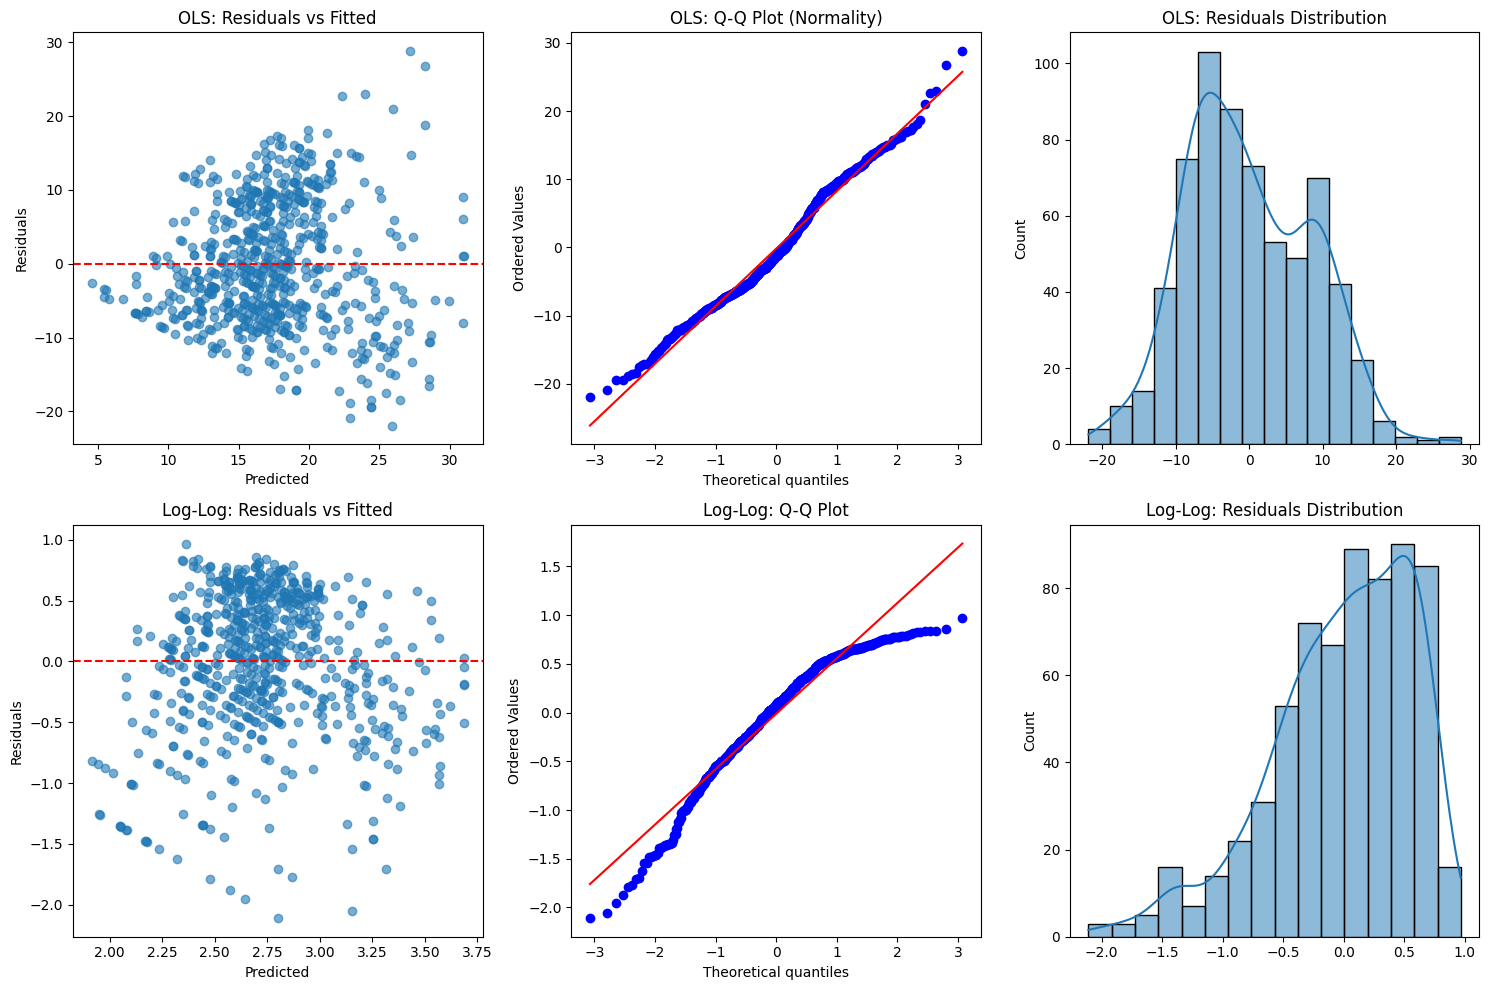


✅ VALIDATION COMPLETE:
- R² & MSE: Quantitative fit
- Residual plots: No patterns = good model
- Q-Q plots: Straight line = normal residuals


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# 1. Linear OLS Residuals
ols_pred = ols_model.predict(X_test_sm)
ols_resid = y_test - ols_pred
axes[0,0].scatter(ols_pred, ols_resid, alpha=0.6)
axes[0,0].axhline(0, color='r', linestyle='--')
axes[0,0].set_xlabel('Predicted'); axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('OLS: Residuals vs Fitted')

# OLS Q-Q plot
stats.probplot(ols_resid, dist="norm", plot=axes[0,1])
axes[0,1].set_title('OLS: Q-Q Plot (Normality)')

sns.histplot(ols_resid, kde=True, ax=axes[0,2])
axes[0,2].set_title('OLS: Residuals Distribution')

# 2. Log-Log Residuals
loglog_pred = loglog_model.predict(X_log_test_sm)
loglog_resid = y_log_test - loglog_pred
axes[1,0].scatter(loglog_pred, loglog_resid, alpha=0.6)
axes[1,0].axhline(0, color='r', linestyle='--')
axes[1,0].set_xlabel('Predicted'); axes[1,0].set_ylabel('Residuals')
axes[1,0].set_title('Log-Log: Residuals vs Fitted')

stats.probplot(loglog_resid, dist="norm", plot=axes[1,1])
axes[1,1].set_title('Log-Log: Q-Q Plot')

sns.histplot(loglog_resid, kde=True, ax=axes[1,2])
axes[1,2].set_title('Log-Log: Residuals Distribution')

plt.tight_layout()
plt.show()

print("\n✅ VALIDATION COMPLETE:")
print("- R² & MSE: Quantitative fit")
print("- Residual plots: No patterns = good model")
print("- Q-Q plots: Straight line = normal residuals")

**Conclusion :- **


The best overall predictive model for demand is the Random Forest, but the best model for price elasticity specifically is the Log-Log OLS.

The Log-Log OLS model directly gives us the exact price elasticity as the coefficient on log_price, which in our results is about -0.2218. This coefficient has a clean interpretation: a 1% increase in price leads to about a 0.22% decrease in bookings, which is exactly what we need for business storytelling and for designing pricing rules based on elasticity. Even though its R² is lower (~0.24), this model is preferred for elasticity because the log–log specification is standard and is easy to explain to stakeholders